In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from itertools import chain
warnings.filterwarnings("ignore")

import os 
os.makedirs("../outputs/reports", exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [2]:
df  = pd.read_csv("../data/processed/tickets_clean.csv")
kpi = pd.read_csv("../data/processed/weekly_kpi.csv")

tag_cols = [c for c in df.columns if c.startswith("tag_")]

def collect_tags(row):
    tags = []
    for col in tag_cols:
        val = str(row[col]).strip()
        if val and val.lower() not in ["nan", ""]:
            tags.append(val)
    return tags

df["tags_list"] = df.apply(collect_tags, axis=1)

print("tickets:", len(df))
print("kpi rows:", len(kpi))

tickets: 28580
kpi rows: 10


In [3]:
summary = {
    "total_tickets"       : len(df),
    "high_priority_count" : (df["priority"] == "high").sum(),
    "high_priority_pct"   : round((df["priority"] == "high").mean() * 100, 2),
    "incident_count"      : (df["type"] == "Incident").sum(),
    "incident_pct"        : round((df["type"] == "Incident").mean() * 100, 2),
    "en_count"            : (df["language"] == "en").sum(),
    "de_count"            : (df["language"] == "de").sum(),
    "top_queue"           : df["queue"].value_counts().index[0],
    "top_queue_count"     : df["queue"].value_counts().iloc[0],
}

summary_df = pd.DataFrame(list(summary.items()), columns=["metric", "value"])
print("Weekly KPI Summary")
print(summary_df.to_string(index=False))

Weekly KPI Summary
             metric             value
      total_tickets             28580
high_priority_count             11175
  high_priority_pct              39.1
     incident_count             11465
       incident_pct             40.12
           en_count             16335
           de_count             12245
          top_queue Technical Support
    top_queue_count              8361


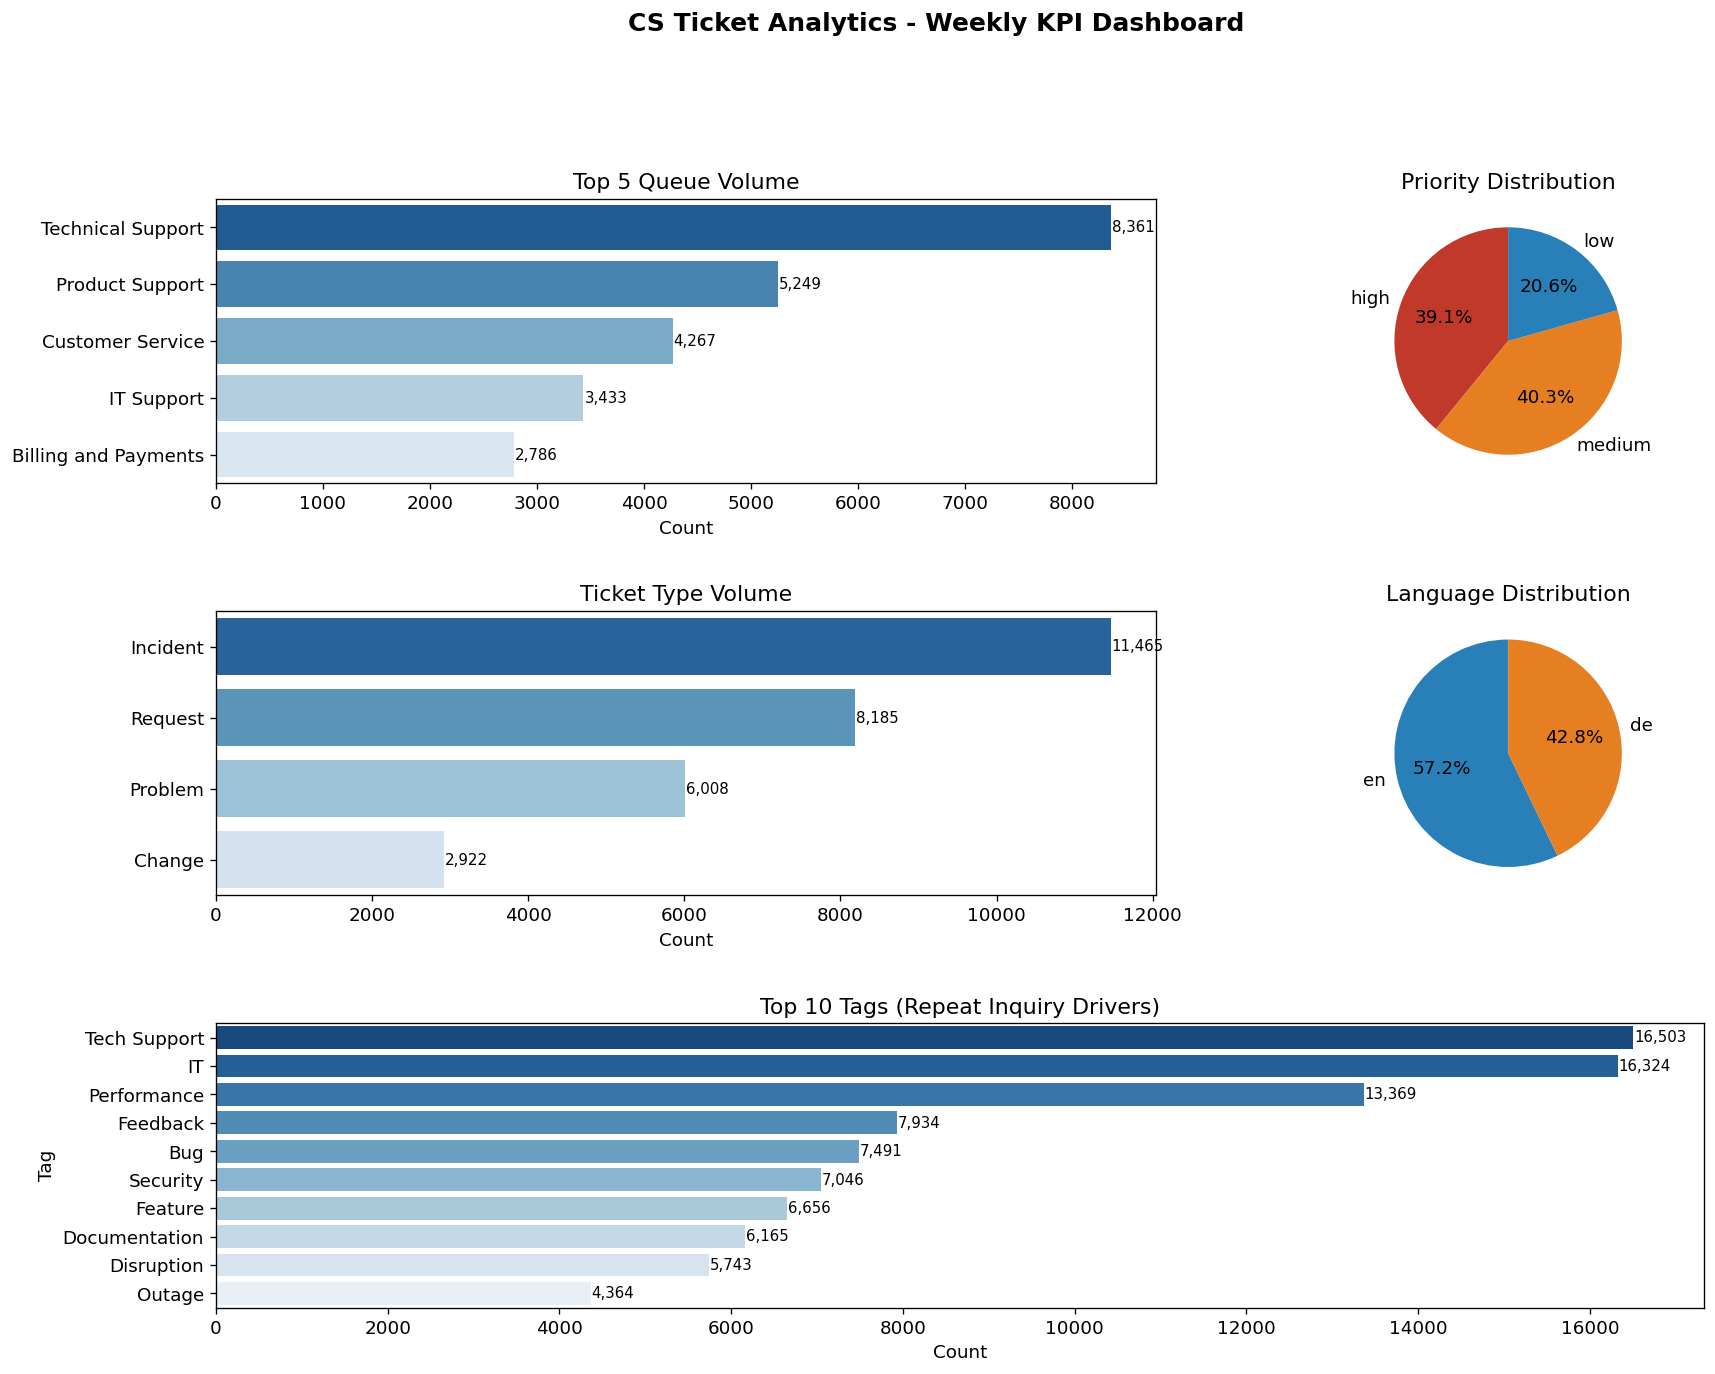

In [4]:
from collections import Counter
import itertools

all_tags     = list(chain.from_iterable(df["tags_list"]))
tag_counter  = Counter(all_tags)
top10_tags   = pd.DataFrame(tag_counter.most_common(10), columns=["tag", "count"])
top5_queues  = df["queue"].value_counts().head(5).reset_index()
top5_queues.columns = ["queue", "count"]

priority_counts = df["priority"].value_counts().reindex(["high", "medium", "low"])
type_counts     = df["type"].value_counts()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

# (0,0) ~ (0,1) : queue 볼륨
ax1 = fig.add_subplot(gs[0, :2])
sns.barplot(data=top5_queues, x="count", y="queue", palette="Blues_r", ax=ax1)
ax1.set_title("Top 5 Queue Volume")
ax1.set_xlabel("Count")
ax1.set_ylabel("")
for i, v in enumerate(top5_queues["count"]):
    ax1.text(v + 10, i, f"{v:,}", va="center", fontsize=9)

# (0,2) : priority 파이
ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(
    priority_counts.values,
    labels=priority_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#c0392b", "#e67e22", "#2980b9"]
)
ax2.set_title("Priority Distribution")

# (1,0) ~ (1,1) : type 바차트
ax3 = fig.add_subplot(gs[1, :2])
sns.barplot(x=type_counts.values, y=type_counts.index, palette="Blues_r", ax=ax3)
ax3.set_title("Ticket Type Volume")
ax3.set_xlabel("Count")
ax3.set_ylabel("")
for i, v in enumerate(type_counts.values):
    ax3.text(v + 10, i, f"{v:,}", va="center", fontsize=9)

# (1,2) : language 파이
ax4 = fig.add_subplot(gs[1, 2])
lang_counts = df["language"].value_counts()
ax4.pie(
    lang_counts.values,
    labels=lang_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2980b9", "#e67e22"]
)
ax4.set_title("Language Distribution")

# (2,0) ~ (2,2) : top 10 tags
ax5 = fig.add_subplot(gs[2, :])
sns.barplot(data=top10_tags, x="count", y="tag", palette="Blues_r", ax=ax5)
ax5.set_title("Top 10 Tags (Repeat Inquiry Drivers)")
ax5.set_xlabel("Count")
ax5.set_ylabel("Tag")
for i, v in enumerate(top10_tags["count"]):
    ax5.text(v + 10, i, f"{v:,}", va="center", fontsize=9)

fig.suptitle("CS Ticket Analytics - Weekly KPI Dashboard", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("../outputs/figures/06_weekly_dashboard.png", bbox_inches="tight")
plt.show()

In [6]:
kpi.to_csv("../outputs/reports/weekly_kpi_sample.csv", index=False)
summary_df.to_csv("../outputs/reports/weekly_summary.csv", index=False)

print("weekly_kpi_sample.csv")
print("weekly_summary.csv")

weekly_kpi_sample.csv
weekly_summary.csv
